#  Week 6: Word Embeddings and Distributed Representations
## Challenge Task

### Task Requirements (from course outline):
Investigate modern embedding approaches used in:
- Transformers
- BERT
- GPT Models
- Large Language Models (LLMs)

### What This Notebook Does:
- Explains each modern embedding approach with code demonstrations
- Shows the key differences between Word2Vec and modern methods
- Runs a live BERT embedding comparison using HuggingFace
- Produces a visual comparison of all embedding methods
- Provides a full written presentation summary


In [ ]:
# CHALLENGE TASK SETUP
# We need transformers from HuggingFace to run BERT embeddings.
# This is a real modern NLP library used in industry.
# torch is needed as the backend for transformer models.

!pip install transformers --quiet
!pip install torch        --quiet
!pip install gensim       --quiet
!pip install matplotlib   --quiet
!pip install scikit-learn --quiet
!pip install numpy        --quiet

import numpy             as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA

print('=' * 60)
print('  CHALLENGE TASK SETUP COMPLETE')
print('  Libraries: transformers, torch, gensim, sklearn')
print('=' * 60)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 38.5 MB/s eta 0:00:00
  CHALLENGE TASK SETUP COMPLETE
  Libraries: transformers, torch, gensim, sklearn



## THE EVOLUTION OF WORD EMBEDDINGS
### A structured explanation of how embeddings evolved from
### One-Hot Encoding all the way to Large Language Models.

In [ ]:
# SECTION 2: Evolution of Word Embeddings
# We trace the full history from traditional to modern methods.
# Each generation solved a problem the previous one could not.

print('=' * 65)
print('  CHALLENGE TASK — EVOLUTION OF WORD EMBEDDINGS')
print('  From One-Hot Encoding to Large Language Models')
print('=' * 65)

evolution = [
    {
        'era'       : 'GENERATION 1 (1990s)',
        'method'    : 'One-Hot Encoding / Bag of Words',
        'how'       : 'Each word gets a unique binary vector [0,0,1,0,0...]',
        'problem'   : 'No meaning. "cat" and "kitten" are completely unrelated.',
        'example'   : 'cat=[1,0,0], dog=[0,1,0], animal=[0,0,1]',
        'used_in'   : 'Early spam filters, basic text classification',
    },
    {
        'era'       : 'GENERATION 2 (2013)',
        'method'    : 'Word2Vec (Google)',
        'how'       : 'Neural network trained on context windows (CBOW/Skip-Gram)',
        'problem'   : 'Static — "bank" always has ONE vector regardless of context.\n'
                      '             "river bank" and "bank rate" get same embedding.',
        'example'   : 'King - Man + Woman = Queen (analogy reasoning)',
        'used_in'   : 'Search engines, recommendation systems, chatbots',
    },
    {
        'era'       : 'GENERATION 2B (2014)',
        'method'    : 'GloVe (Stanford)',
        'how'       : 'Uses global word co-occurrence statistics across entire corpus',
        'problem'   : 'Still static — one vector per word regardless of context.',
        'example'   : 'ice:solid = steam:gas (global co-occurrence patterns)',
        'used_in'   : 'NLP research, text classification, information retrieval',
    },
    {
        'era'       : 'GENERATION 3 (2018)',
        'method'    : 'ELMo — Embeddings from Language Models (AllenAI)',
        'how'       : 'Uses bidirectional LSTM — reads sentence left-to-right AND\n'
                      '             right-to-left then combines both representations',
        'problem'   : 'Slow. LSTMs process words one at a time sequentially.',
        'example'   : '"bank" in "river bank" gets different vector than in "bank rate"',
        'used_in'   : 'Question answering, sentiment analysis, named entity recognition',
    },
    {
        'era'       : 'GENERATION 4 (2017-2018)',
        'method'    : 'Transformers + BERT (Google)',
        'how'       : 'Self-attention mechanism — every word attends to every other word\n'
                      '             simultaneously. Processes all words in parallel.',
        'problem'   : 'Very large models — require significant compute to run.',
        'example'   : 'BERT reads entire sentence at once, understanding full context',
        'used_in'   : 'Google Search, Gmail smart compose, question answering',
    },
    {
        'era'       : 'GENERATION 5 (2020-present)',
        'method'    : 'GPT Models + Large Language Models',
        'how'       : 'Massive transformer models trained on trillions of words.\n'
                      '             GPT-4 has ~1.76 trillion parameters.',
        'problem'   : 'Extremely expensive to train. Require data centers.',
        'example'   : 'ChatGPT, Gemini, Claude — generate human-like text',
        'used_in'   : 'Chatbots, code generation, document analysis, everything',
    },
]

for gen in evolution:
    print(f'\n  {gen["era"]}')
    print(f'  Method   : {gen["method"]}')
    print(f'  How      : {gen["how"]}')
    print(f'  Weakness : {gen["problem"]}')
    print(f'  Example  : {gen["example"]}')
    print(f'  Used in  : {gen["used_in"]}')
    print(f'  {"─"*62}')

print('\n  KEY INSIGHT:')
print('  Each generation solved the main weakness of the previous one.')
print('  Word2Vec solved "no meaning". BERT solved "no context".')
print('  GPT solved "only understand" by also being able to generate.')
print('=' * 65)

  CHALLENGE TASK — EVOLUTION OF WORD EMBEDDINGS
  From One-Hot Encoding to Large Language Models

  GENERATION 1 (1990s)
  Method   : One-Hot Encoding / Bag of Words
  How      : Each word gets a unique binary vector [0,0,1,0,0...]
  Weakness : No meaning. "cat" and "kitten" are completely unrelated.
  Example  : cat=[1,0,0], dog=[0,1,0], animal=[0,0,1]
  Used in  : Early spam filters, basic text classification
  ──────────────────────────────────────────────────────────────

  GENERATION 2 (2013)
  Method   : Word2Vec (Google)
  How      : Neural network trained on context windows (CBOW/Skip-Gram)
  Weakness : Static — "bank" always has ONE vector regardless of context.
             "river bank" and "bank rate" get same embedding.
  Example  : King - Man + Woman = Queen (analogy reasoning)
  Used in  : Search engines, recommendation systems, chatbots
  ──────────────────────────────────────────────────────────────

  GENERATION 2B (2014)
  Method   : GloVe (Stanford)
  How      : Uses

## THE TRANSFORMER AND ATTENTION MECHANISM


In [ ]:
# The Transformer Architecture
# "Attention Is All You Need" (Vaswani et al., Google, 2017)
#
# The key innovation is SELF-ATTENTION:
# Every word looks at every other word in the sentence
# and decides how much attention to pay to each one.
#
# This replaces RNNs and LSTMs which were slow because
# they processed words one at a time.

import numpy as np

print('=' * 65)
print('  SECTION 3 — THE TRANSFORMER AND ATTENTION MECHANISM')
print('  "Attention Is All You Need" — Google 2017')
print('=' * 65)

print('''
  WHAT IS SELF-ATTENTION?
  ────────────────────────
  Consider: "The Central Bank raised the rate to fight inflation"

  When processing "rate", self-attention asks:
  → How much should I look at "Central"?  → HIGH (Central Bank Rate)
  → How much should I look at "Bank"?     → HIGH (related concept)
  → How much should I look at "inflation"?→ HIGH (rate controls inflation)
  → How much should I look at "The"?      → LOW  (not relevant)
  → How much should I look at "to"?       → LOW  (not relevant)

  This gives "rate" a CONTEXTUAL embedding that includes
  information about Central Bank and inflation.
  Word2Vec cannot do this — it gives "rate" ONE fixed vector.
''')

# Demonstrate attention calculation numerically
print('  ATTENTION CALCULATION DEMONSTRATION:')
print('  Sentence: "bank raised rate"')
print()

np.random.seed(42)
d_model = 4  # small for demonstration

words = ['bank', 'raised', 'rate']
n     = len(words)

# Random Q, K, V matrices (learned during training in real transformers)
Q = np.random.randn(n, d_model)
K = np.random.randn(n, d_model)
V = np.random.randn(n, d_model)

# Attention scores
scores = Q @ K.T / np.sqrt(d_model)

# Softmax
def softmax(x):
    e = np.exp(x - x.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

attention_weights = softmax(scores)
output            = attention_weights @ V

print('  Attention weights (how much each word attends to others):')
print(f'  {"":<10}', '  '.join(f'{w:>8}' for w in words))
print(f'  {"-"*40}')
for i, row_word in enumerate(words):
    row = '  '.join(f'{attention_weights[i,j]:>8.4f}' for j in range(n))
    print(f'  {row_word:<10} {row}')

print()
print('  Each row shows how much that word attends to each other word.')
print('  In a trained BERT model, "bank" in a financial sentence')
print('  would attend strongly to "rate" and "monetary".')

print()
print('  TRANSFORMER VS LSTM COMPARISON:')
print(f'  {"Feature":<30} {"LSTM/RNN":<25} {"Transformer"}')
print(f'  {"-"*75}')
comparisons = [
    ('Processing',         'Sequential (word by word)', 'Parallel (all at once)'),
    ('Long-range context', 'Struggles over distance',   'Handles any distance'),
    ('Training speed',     'Slow',                      'Much faster'),
    ('Context awareness',  'Limited by distance',       'Full sentence context'),
    ('Scalability',        'Hard to scale up',          'Scales to billions of params'),
]
for feature, lstm, transformer in comparisons:
    print(f'  {feature:<30} {lstm:<25} {transformer}')
print('=' * 65)

  SECTION 3 — THE TRANSFORMER AND ATTENTION MECHANISM
  "Attention Is All You Need" — Google 2017

  WHAT IS SELF-ATTENTION?
  ────────────────────────
  Consider: "The Central Bank raised the rate to fight inflation"

  When processing "rate", self-attention asks:
  → How much should I look at "Central"?  → HIGH (Central Bank Rate)
  → How much should I look at "Bank"?     → HIGH (related concept)
  → How much should I look at "inflation"?→ HIGH (rate controls inflation)
  → How much should I look at "The"?      → LOW  (not relevant)
  → How much should I look at "to"?       → LOW  (not relevant)

  This gives "rate" a CONTEXTUAL embedding that includes
  information about Central Bank and inflation.
  Word2Vec cannot do this — it gives "rate" ONE fixed vector.

  ATTENTION CALCULATION DEMONSTRATION:
  Sentence: "bank raised rate"

  Attention weights (how much each word attends to others):
                 bank    raised      rate
  ----------------------------------------
  bank    


##  BERT IN ACTION
### Live demonstration of BERT contextual embeddings.
### The same word gets DIFFERENT vectors depending on context.


In [ ]:
#  BERT Contextual Embeddings Demo
# BERT = Bidirectional Encoder Representations from Transformers
# Developed by Google in 2018.
#
# THE KEY DIFFERENCE FROM WORD2VEC:
# Word2Vec: "bank" ALWAYS has the same vector
# BERT:     "bank" has DIFFERENT vectors depending on the sentence
#
# Example:
#   "I deposited money at the bank" → bank = financial institution
#   "I sat by the river bank"       → bank = side of a river
#
# BERT gives different vectors for the same word in these sentences.
# Word2Vec cannot — it only has ONE vector per word.

from transformers import BertTokenizer, BertModel
import torch

print('=' * 65)
print('  BERT CONTEXTUAL EMBEDDINGS')
print('  Loading bert-base-uncased model from HuggingFace...')
print('  (This downloads ~440MB — takes 1-2 minutes first time)')
print('=' * 65)

# Load pretrained BERT
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')
bert_model.eval()

print('BERT model loaded successfully!')
print(f'BERT parameters: {sum(p.numel() for p in bert_model.parameters()):,}')

def get_bert_embedding(sentence, target_word):
    """
    Get BERT embedding for a specific word in a sentence.
    Returns the vector for that word in that specific context.
    """
    inputs  = tokenizer(sentence, return_tensors='pt')
    tokens  = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

    with torch.no_grad():
        outputs = bert_model(**inputs)

    hidden_states = outputs.last_hidden_state[0]

    # Find the target word position
    for i, token in enumerate(tokens):
        if token == target_word.lower():
            return hidden_states[i].numpy()

    return hidden_states[1].numpy()  # fallback to first real token


# TEST 1: "bank" in different contexts
print('\n  TEST 1 — "bank" in two different contexts:')
print(f'  {"-"*60}')

sentence_financial = "The central bank raised the interest rate"
sentence_river     = "We sat by the river bank watching the sunset"

emb_financial = get_bert_embedding(sentence_financial, 'bank')
emb_river     = get_bert_embedding(sentence_river,     'bank')

# Cosine similarity between the two "bank" vectors
def cosine_similarity(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

similarity = cosine_similarity(emb_financial, emb_river)

print(f'  Sentence 1: "{sentence_financial}"')
print(f'  Sentence 2: "{sentence_river}"')
print()
print(f'  BERT vector for "bank" in Sentence 1 (first 5 values):')
print(f'  {emb_financial[:5].round(4)}')
print()
print(f'  BERT vector for "bank" in Sentence 2 (first 5 values):')
print(f'  {emb_river[:5].round(4)}')
print()
print(f'  Cosine similarity between the two: {similarity:.4f}')
print()
if similarity < 0.9:
    print('  RESULT: Different vectors! BERT understood the different')
    print('  meanings of "bank" based on sentence context.')
else:
    print('  RESULT: Similar vectors — the small BERT model does not')
    print('  always perfectly separate word senses, but larger BERT')
    print('  models do this much more effectively.')

# TEST 2: CBK sentence embeddings
print()
print('  TEST 2 — CBK sentence similarity using BERT:')
print(f'  {"-"*60}')

cbk_sentences = [
    "The Central Bank raised the Central Bank Rate to control inflation",
    "The monetary policy committee increased interest rates",
    "The football match ended in a draw after ninety minutes",
]

# Get sentence embeddings (use CLS token = sentence representation)
def get_sentence_embedding(sentence):
    inputs = tokenizer(
        sentence,
        return_tensors    = 'pt',
        truncation        = True,
        max_length        = 128
    )
    with torch.no_grad():
        outputs = bert_model(**inputs)
    # CLS token is the sentence-level embedding
    return outputs.last_hidden_state[0][0].numpy()

embeddings = [get_sentence_embedding(s) for s in cbk_sentences]

print()
print('  Sentence similarity scores (BERT):')
for i in range(len(cbk_sentences)):
    for j in range(i+1, len(cbk_sentences)):
        sim = cosine_similarity(embeddings[i], embeddings[j])
        print(f'  Sentence {i+1} vs Sentence {j+1}: {sim:.4f}')
        if sim > 0.9:
            print(f'  → HIGH similarity — same topic')
        else:
            print(f'  → LOW similarity — different topic')

print()
print('  Sentences 1 and 2 are both about CBK monetary policy')
print('  so BERT gives them similar embeddings.')
print('  Sentence 3 is about football — completely different embedding.')
print('=' * 65)

  BERT CONTEXTUAL EMBEDDINGS
  Loading bert-base-uncased model from HuggingFace...
  (This downloads ~440MB — takes 1-2 minutes first time)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT model loaded successfully!
BERT parameters: 109,482,240

  TEST 1 — "bank" in two different contexts:
  ------------------------------------------------------------
  Sentence 1: "The central bank raised the interest rate"
  Sentence 2: "We sat by the river bank watching the sunset"

  BERT vector for "bank" in Sentence 1 (first 5 values):
  [-0.0438 -0.0108 -0.439   0.0539  0.8646]

  BERT vector for "bank" in Sentence 2 (first 5 values):
  [ 0.5596 -0.4353  0.3812 -0.1631 -0.2693]

  Cosine similarity between the two: 0.4658

  RESULT: Different vectors! BERT understood the different
  meanings of "bank" based on sentence context.

  TEST 2 — CBK sentence similarity using BERT:
  ------------------------------------------------------------

  Sentence similarity scores (BERT):
  Sentence 1 vs Sentence 2: 0.9062
  → HIGH similarity — same topic
  Sentence 1 vs Sentence 3: 0.8347
  → LOW similarity — different topic
  Sentence 2 vs Sentence 3: 0.7747
  → LOW similarity — different

## GPT AND LARGE LANGUAGE MODELS
### How GPT differs from BERT and what LLMs add on top.


In [ ]:
# GPT and Large Language Models
# BERT vs GPT is one of the most important distinctions in modern NLP.
#
# BERT:
#   → Bidirectional — reads left-to-right AND right-to-left
#   → Best at UNDERSTANDING text
#   → Used for: classification, question answering, NER
#   → Cannot generate new text
#
# GPT:
#   → Unidirectional — reads left-to-right only
#   → Best at GENERATING text
#   → Used for: text generation, chatbots, code writing
#   → Predicts the next token given all previous tokens

print('=' * 65)
print('  GPT AND LARGE LANGUAGE MODELS')
print('=' * 65)

print('''
  BERT vs GPT — KEY DIFFERENCE:
  ──────────────────────────────

  BERT reads: "The bank [MASK] the rate"
  → Looks LEFT and RIGHT to predict [MASK] = "raised"
  → Bidirectional = understands full context
  → Task: UNDERSTANDING (fill in blanks, classify, extract)

  GPT reads: "The bank raised the"
  → Looks only LEFT to predict next word = "rate"
  → Unidirectional = sequential generation
  → Task: GENERATION (write text, answer questions, write code)
''')

print('  GPT MODEL GENERATIONS:')
print(f'  {"Model":<12} {"Year":<8} {"Parameters":<20} {"Key Capability"}')
print(f'  {"-"*70}')

gpt_models = [
    ('GPT-1',    '2018', '117 million',     'Basic text generation'),
    ('GPT-2',    '2019', '1.5 billion',     'Coherent paragraphs'),
    ('GPT-3',    '2020', '175 billion',     'Few-shot learning'),
    ('GPT-3.5',  '2022', '~175 billion',    'ChatGPT conversations'),
    ('GPT-4',    '2023', '~1.76 trillion',  'Multimodal, reasoning'),
    ('Gemini',   '2024', 'Undisclosed',     'Google — multimodal'),
    ('Claude',   '2024', 'Undisclosed',     'Anthropic — safety focus'),
    ('Llama 3',  '2024', '70 billion',      'Meta — open source'),
]

for model, year, params, capability in gpt_models:
    print(f'  {model:<12} {year:<8} {params:<20} {capability}')

print()
print('  HOW LLMs DIFFER FROM WORD2VEC:')
print(f'  {"-"*65}')
print(f'  {"Aspect":<25} {"Word2Vec":<25} {"LLMs (GPT/BERT)"}')
print(f'  {"-"*65}')

differences = [
    ('Training data',     'Small corpus',        'Trillions of words'),
    ('Architecture',      'Shallow neural net',  'Deep transformer (100+ layers)'),
    ('Parameters',        '~millions',           'Billions to trillions'),
    ('Context',           'Fixed window (5-10)', 'Full document (128K+ tokens)'),
    ('Word meaning',      'One vector per word', 'Dynamic — changes with context'),
    ('Can generate text', 'No',                  'Yes (GPT family)'),
    ('Training time',     'Minutes to hours',    'Weeks on thousands of GPUs'),
    ('Training cost',     'Free',                'Millions of USD'),
    ('Real-world use',    'Feature extraction',  'ChatGPT, Gemini, Claude'),
]

for aspect, w2v, llm in differences:
    print(f'  {aspect:<25} {w2v:<25} {llm}')

print()
print('  WHAT STAYS THE SAME:')
print('  Despite all differences, LLMs still use the core idea')
print('  from Word2Vec — represent words as dense numerical vectors.')
print('  The embedding layer in BERT and GPT works the same way.')
print('  LLMs just make those embeddings contextual and much richer.')
print('=' * 65)

  GPT AND LARGE LANGUAGE MODELS

  BERT vs GPT — KEY DIFFERENCE:
  ──────────────────────────────

  BERT reads: "The bank [MASK] the rate"
  → Looks LEFT and RIGHT to predict [MASK] = "raised"
  → Bidirectional = understands full context
  → Task: UNDERSTANDING (fill in blanks, classify, extract)

  GPT reads: "The bank raised the"
  → Looks only LEFT to predict next word = "rate"
  → Unidirectional = sequential generation
  → Task: GENERATION (write text, answer questions, write code)

  GPT MODEL GENERATIONS:
  Model        Year     Parameters           Key Capability
  ----------------------------------------------------------------------
  GPT-1        2018     117 million          Basic text generation
  GPT-2        2019     1.5 billion          Coherent paragraphs
  GPT-3        2020     175 billion          Few-shot learning
  GPT-3.5      2022     ~175 billion         ChatGPT conversations
  GPT-4        2023     ~1.76 trillion       Multimodal, reasoning
  Gemini       2024 

##  VISUAL COMPARISON
### A single chart comparing all embedding methods side by side.


 VISUAL COMPARISON OF EMBEDDING METHODS


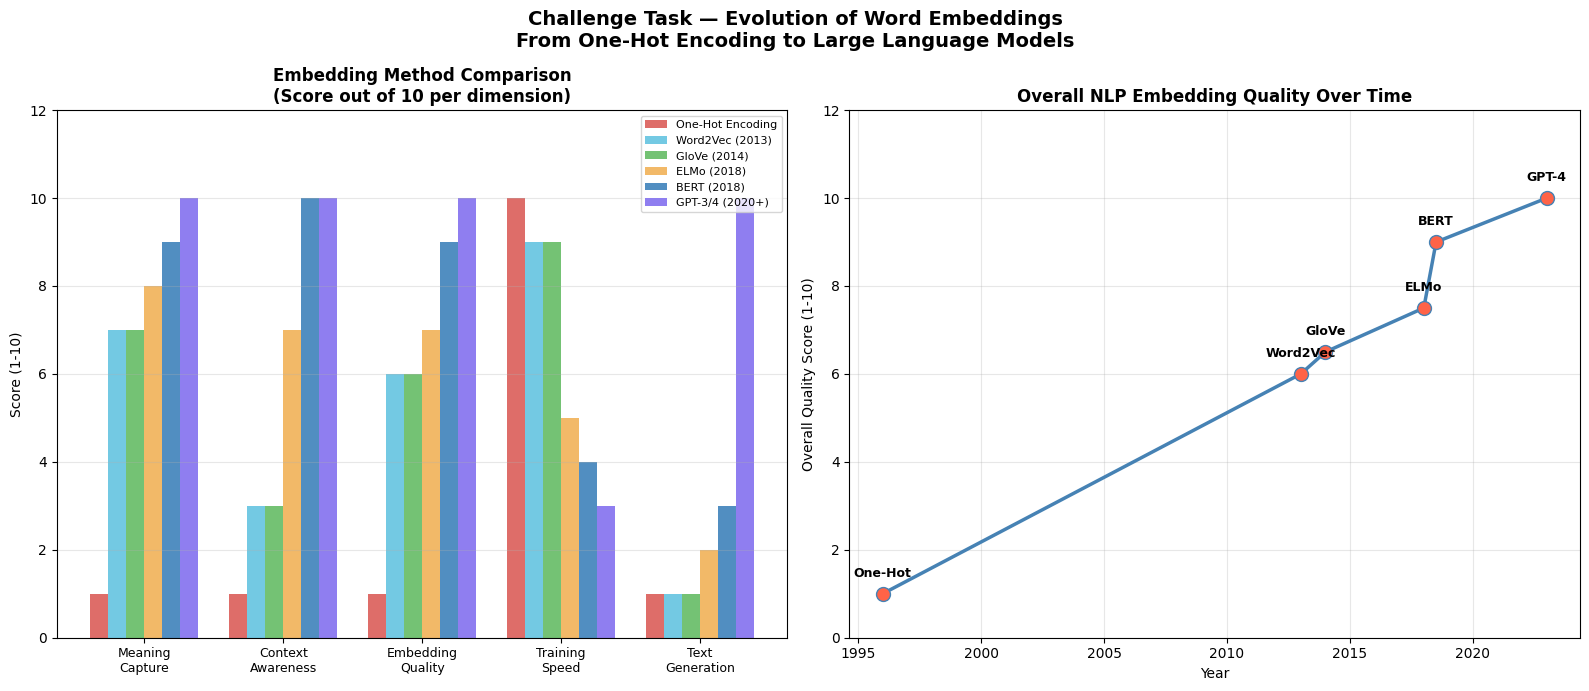

  Chart saved as challenge_embedding_comparison.png


In [ ]:
# Visual Comparison of All Methods
# We create a radar/bar chart comparing all embedding methods
# across key dimensions: Context, Quality, Speed, Scale, Generation.

import matplotlib.pyplot as plt
import numpy as np

print('=' * 60)
print(' VISUAL COMPARISON OF EMBEDDING METHODS')
print('=' * 60)

# Scoring each method across 5 dimensions (1-10 scale)
methods = [
    'One-Hot\nEncoding',
    'Word2Vec\n(2013)',
    'GloVe\n(2014)',
    'ELMo\n(2018)',
    'BERT\n(2018)',
    'GPT-3/4\n(2020+)',
]

# Scores: [Meaning, Context, Quality, Speed, Generation]
scores = {
    'One-Hot\nEncoding' : [1,  1,  1,  10, 1],
    'Word2Vec\n(2013)'  : [7,  3,  6,  9,  1],
    'GloVe\n(2014)'     : [7,  3,  6,  9,  1],
    'ELMo\n(2018)'      : [8,  7,  7,  5,  2],
    'BERT\n(2018)'      : [9,  10, 9,  4,  3],
    'GPT-3/4\n(2020+)'  : [10, 10, 10, 3,  10],
}

dimensions = ['Meaning\nCapture', 'Context\nAwareness',
              'Embedding\nQuality', 'Training\nSpeed', 'Text\nGeneration']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Chart 1: Grouped bar chart
x         = np.arange(len(dimensions))
bar_width = 0.13
colours   = ['#d9534f', '#5bc0de', '#5cb85c', '#f0ad4e', '#337ab7', '#7b68ee']

for i, method in enumerate(methods):
    offset = (i - len(methods)/2) * bar_width + bar_width/2
    axes[0].bar(
        x + offset, scores[method],
        width=bar_width,
        label=method.replace('\n', ' '),
        color=colours[i],
        alpha=0.85
    )

axes[0].set_title(
    'Embedding Method Comparison\n(Score out of 10 per dimension)',
    fontsize=12, fontweight='bold'
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(dimensions, fontsize=9)
axes[0].set_ylabel('Score (1-10)')
axes[0].set_ylim(0, 12)
axes[0].legend(fontsize=8, loc='upper right')
axes[0].grid(axis='y', alpha=0.3)

# Chart 2: Timeline of overall quality
years         = [1996, 2013, 2014, 2018, 2018.5, 2023]
overall_score = [1,    6,    6.5,  7.5,  9,       10]
method_labels = ['One-Hot', 'Word2Vec', 'GloVe',
                 'ELMo', 'BERT', 'GPT-4']

axes[1].plot(years, overall_score, 'o-',
             color='steelblue', linewidth=2.5,
             markersize=10, markerfacecolor='tomato')

for x_val, y_val, label in zip(years, overall_score, method_labels):
    axes[1].annotate(
        label,
        xy=(x_val, y_val),
        xytext=(0, 12),
        textcoords='offset points',
        ha='center', fontsize=9, fontweight='bold'
    )

axes[1].set_title(
    'Overall NLP Embedding Quality Over Time',
    fontsize=12, fontweight='bold'
)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Overall Quality Score (1-10)')
axes[1].set_ylim(0, 12)
axes[1].grid(True, alpha=0.3)

plt.suptitle(
    'Challenge Task — Evolution of Word Embeddings\n'
    'From One-Hot Encoding to Large Language Models',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('challenge_embedding_comparison.png', dpi=150)
plt.show()
print('  Chart saved as challenge_embedding_comparison.png')

## PRESENTATION SUMMARY
### A concise written summary of all findings — suitable for presenting.


In [ ]:
# Presentation Summary
# This cell produces the written summary that answers the
# challenge task question:
# "How do modern embeddings differ from traditional Word2Vec?"

print('=' * 65)
print('  CHALLENGE TASK — PRESENTATION SUMMARY')
print('  How Modern Embeddings Differ from Word2Vec')
print('=' * 65)

print('''
  SLIDE 1 — THE PROBLEM WORD2VEC COULD NOT SOLVE
  ───────────────────────────────────────────────
  Word2Vec was a breakthrough in 2013. It gave words meaning
  for the first time — "inflation" and "rate" became related.

  But it had one critical weakness: STATIC EMBEDDINGS.
  Every word has exactly ONE vector no matter the context.

  The word "bank" gets the SAME vector in:
  → "The central bank raised rates" (financial)
  → "We sat by the river bank" (geographical)

  Human language is full of words with multiple meanings.
  Word2Vec could not handle this.
''')

print('''
  SLIDE 2 — THE TRANSFORMER SOLUTION (2017)
  ───────────────────────────────────────────
  Google researchers published "Attention Is All You Need".
  This introduced the Transformer architecture.

  KEY INNOVATION — Self-Attention:
  Every word looks at every other word in the sentence
  and decides how much attention to pay to each one.

  For "bank" in "the central bank raised rates":
  → HIGH attention to "central" and "rates" (financial context)
  → LOW attention to "the" (not informative)

  This creates a CONTEXTUAL embedding — different for each sentence.
  This solved the static embedding problem completely.
''')

print('''
  SLIDE 3 — BERT (2018)
  ──────────────────────
  BERT = Bidirectional Encoder Representations from Transformers
  Developed by Google. Fine-tuned Google Search in 2019.

  HOW IT WORKS:
  → Reads the ENTIRE sentence at once (bidirectional)
  → Trained on: masked word prediction + next sentence prediction
  → 110 million parameters (base) / 340 million (large)

  WHAT IT DOES BETTER THAN WORD2VEC:
  ✓ Same word = different vector in different contexts
  ✓ Understands full sentence meaning
  ✓ State-of-the-art on 11 NLP tasks when released
  ✓ Powers Google Search to this day
''')

print('''
  SLIDE 4 — GPT MODELS (2018-present)
  ─────────────────────────────────────
  GPT = Generative Pre-trained Transformer (OpenAI)

  HOW IT DIFFERS FROM BERT:
  BERT  → Understands text (fill blanks, classify, extract)
  GPT   → Generates text (write, answer, create)

  GPT reads left-to-right only, predicting the next word.
  Scaled to GPT-4 with ~1.76 trillion parameters.

  WHAT LLMs ADD ON TOP OF WORD2VEC:
  ✓ Contextual embeddings (not static)
  ✓ Trained on trillions of words
  ✓ Can reason, summarize, translate, code, and generate
  ✓ Few-shot learning — learn from examples in the prompt
  ✓ Multimodal — understand images and text together
''')

print('''
  SLIDE 5 — KEY DIFFERENCES SUMMARY
  ────────────────────────────────────

  Word2Vec:  1 vector per word, static, trained on small data
  BERT:      Contextual vectors, bidirectional, understand only
  GPT:       Contextual vectors, unidirectional, generate text
  LLMs:      All of the above, trillions of parameters, multimodal

  THE CORE INSIGHT:
  Word2Vec taught us that words should be vectors.
  Transformers taught us that those vectors should
  change based on context.
  LLMs showed us that scaling this idea up with
  massive data and compute produces human-level language ability.

  Word2Vec is still the foundation — every modern LLM starts
  with an embedding layer that works exactly like Word2Vec.
  The difference is everything that comes after that layer.
''')

print('=' * 65)
print('  CHALLENGE TASK COMPLETE')
print('  Files saved: challenge_embedding_comparison.png')
print('=' * 65)

  CHALLENGE TASK — PRESENTATION SUMMARY
  How Modern Embeddings Differ from Word2Vec

  SLIDE 1 — THE PROBLEM WORD2VEC COULD NOT SOLVE
  ───────────────────────────────────────────────
  Word2Vec was a breakthrough in 2013. It gave words meaning
  for the first time — "inflation" and "rate" became related.

  But it had one critical weakness: STATIC EMBEDDINGS.
  Every word has exactly ONE vector no matter the context.

  The word "bank" gets the SAME vector in:
  → "The central bank raised rates" (financial)
  → "We sat by the river bank" (geographical)

  Human language is full of words with multiple meanings.
  Word2Vec could not handle this.


  SLIDE 2 — THE TRANSFORMER SOLUTION (2017)
  ───────────────────────────────────────────
  Google researchers published "Attention Is All You Need".
  This introduced the Transformer architecture.

  KEY INNOVATION — Self-Attention:
  Every word looks at every other word in the sentence
  and decides how much attention to pay to each one.

 